In [2]:
import pandas as pd
df = pd.read_csv('C:/Users/hp/Documents/AI Chatbot/sentiment-tweets/data/Tweets.csv')
df.head()


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
df.info()
df['airline_sentiment'].value_counts(normalize=True) * 100


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64

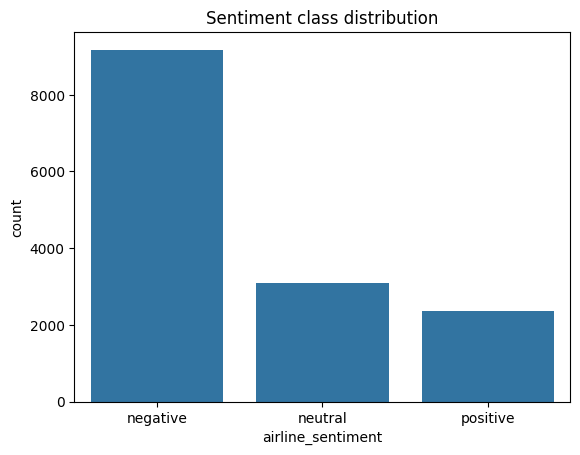

In [4]:
import seaborn as sns, matplotlib.pyplot as plt

sns.countplot(x='airline_sentiment', data=df,
              order=df['airline_sentiment'].value_counts().index)
plt.title('Sentiment class distribution')
plt.show()


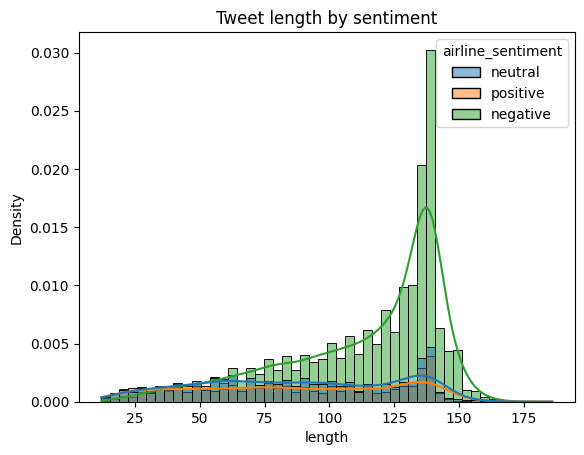

In [5]:
df['length'] = df['text'].str.len()

sns.histplot(data=df, x='length', hue='airline_sentiment',
             bins=50, kde=True, stat='density')
plt.title('Tweet length by sentiment')
plt.show()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


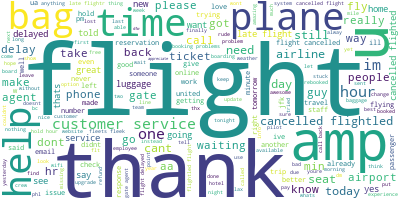

In [ ]:
import nltk, re
from wordcloud import WordCloud
nltk.download('stopwords')
stops = set(nltk.corpus.stopwords.words('english'))

def clean(text):
    text = re.sub(r'http\S+|@\S+|#\S+|[^A-Za-z\s]', '', text.lower())
    return ' '.join(w for w in text.split() if w not in stops)

all_text = ' '.join(df['text'].map(clean))
WordCloud(background_color='white').generate(all_text).to_image()


In [7]:
pct = df['airline_sentiment'].value_counts(normalize=True)*100
print(pct.round(1).to_string())


airline_sentiment
negative    62.7
neutral     21.2
positive    16.1


In [ ]:
df.to_csv('C:/Users/hp/Documents/AI Chatbot/sentiment-tweets/data/cleaned_tweets.csv', index=False)